<a href="https://colab.research.google.com/github/Zewotr/student-performance-prediction-ml-group-4/blob/main/StudentPerformancePred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction

**Course:** Introduction to Machine Learning  
**Department:** Software Engineering  
**University:**  Injibara University  
**Instructor:** Mr. Wanos Guade
**Group Members:** see attached pdf
**Academic Year:** 2025-2026

---

## 1. Introduction
This project aims to predict student performance using the UCI Student Performance dataset. We will explore the factors influencing student grades and apply various Machine Learning algorithms to classify students as 'Pass' or 'Fail' based on their final grades (G3).

In [6]:
# 2. Library Installation
!pip install ucimlrepo xgboost seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# ML Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, mean_absolute_error,
    mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

## 3. Dataset Loading
We use the `ucimlrepo` package to fetch the Student Performance data (ID 320).

In [7]:
# Fetch dataset
student_performance = fetch_ucirepo(id=320)

# Data as pandas dataframes
X = student_performance.data.features
y = student_performance.data.targets

# Combine for EDA purposes
df = pd.concat([X, y], axis=1)

# Display metadata and variables
print("Dataset Metadata:")
display(student_performance.metadata)
print("\nVariable Information:")
display(student_performance.variables)
print("\nFirst 5 Rows:")
display(df.head())

Dataset Metadata:


{'uci_id': 320,
 'name': 'Student Performance',
 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance',
 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv',
 'abstract': 'Predict student performance in secondary education (high school). ',
 'area': 'Social Science',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 649,
 'num_features': 30,
 'feature_types': ['Integer'],
 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'],
 'target_col': ['G1', 'G2', 'G3'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2008,
 'last_updated': 'Fri Jan 05 2024',
 'dataset_doi': '10.24432/C5TG7T',
 'creators': ['Paulo Cortez'],
 'intro_paper': {'ID': 360,
  'type': 'NATIVE',
  'title': 'Using data mining to predict secondary school student performance',
  'authors': 'P. Cortez, A. M. G. Silva',
  'venue': 'Proceedings of 5th Ann


Variable Information:


,name,role,type,demographic,description,units,missing_values
0,school,Feature,Categorical,None,student's school (binary: 'GP' - Gabriel Perei...,None,no
1,sex,Feature,Binary,Sex,student's sex (binary: 'F' - female or 'M' - m...,None,no
2,age,Feature,Integer,Age,student's age (numeric: from 15 to 22),None,no
3,address,Feature,Categorical,None,student's home address type (binary: 'U' - urb...,None,no
4,famsize,Feature,Categorical,Other,family size (binary: 'LE3' - less or equal to ...,None,no
5,Pstatus,Feature,Categorical,Other,parent's cohabitation status (binary: 'T' - li...,None,no
6,Medu,Feature,Integer,Education Level,"mother's education (numeric: 0 - none, 1 - pr...",None,no
7,Fedu,Feature,Integer,Education Level,"father's education (numeric: 0 - none, 1 - pr...",None,no
8,Mjob,Feature,Categorical,Occupation,"mother's job (nominal: 'teacher', 'health' car...",None,no
9,Fjob,Feature,Categorical,Occupation,"father's job (nominal: 'teacher', 'health' car...",None,no



First 5 Rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 4. Exploratory Data Analysis (EDA)
In this section, we analyze the structure of the data and visualize the relationships between features.

Dataset Shape: (649, 33)

Missing Values:
0


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


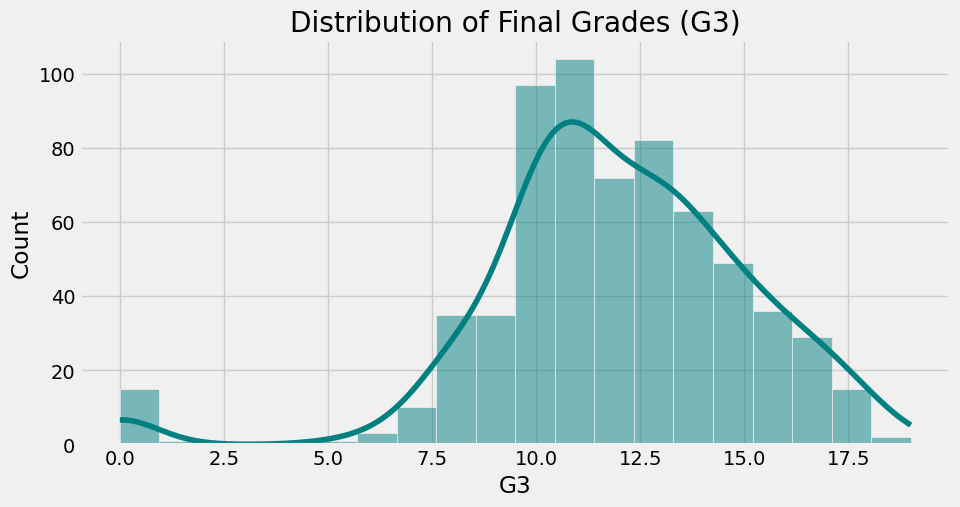

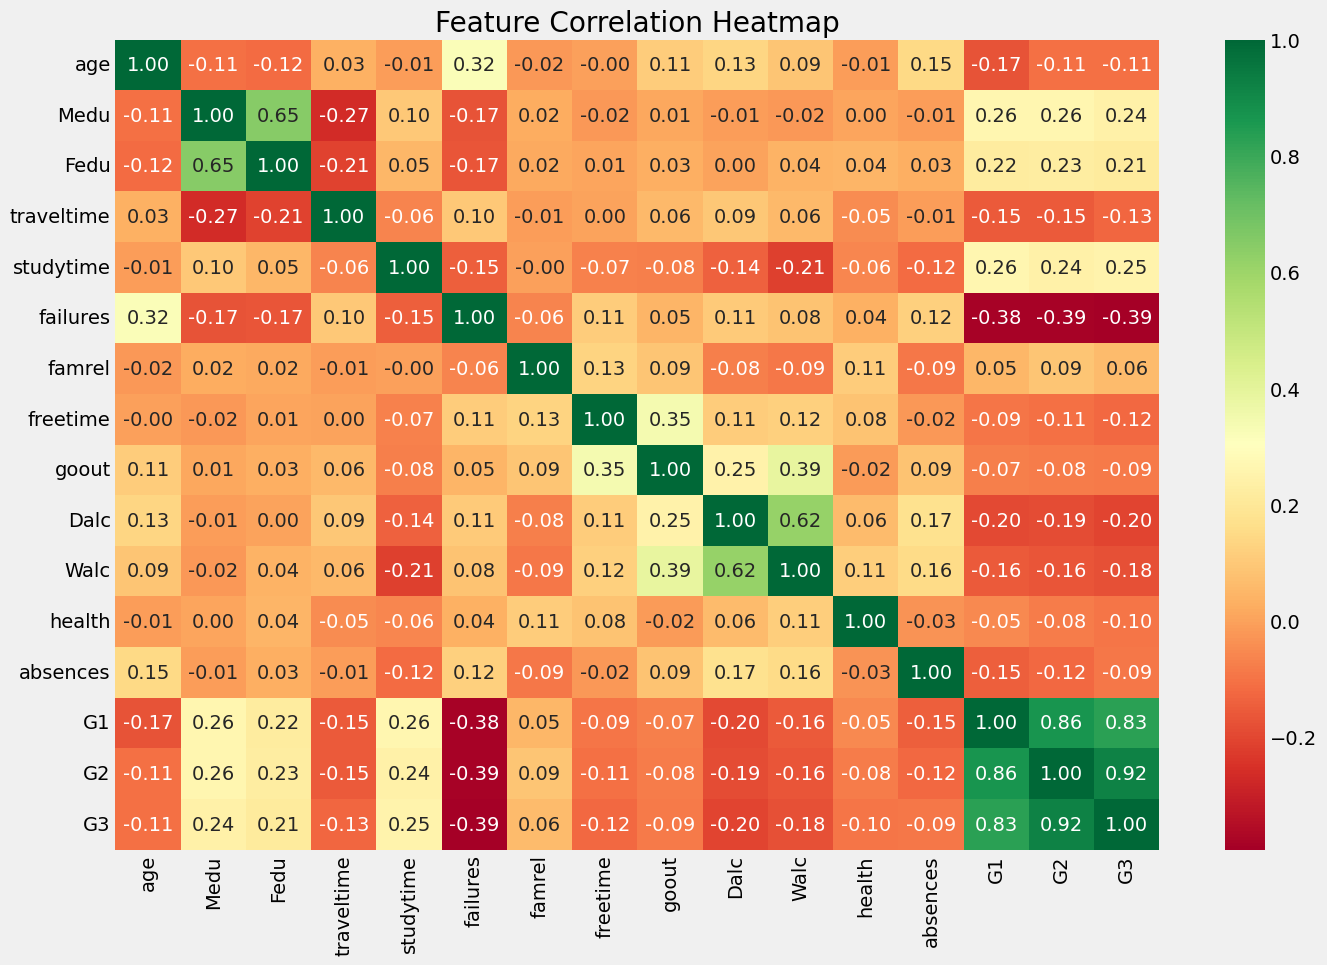

In [8]:
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values:")
print(df.isnull().sum().sum())

# Statistical Summary
display(df.describe())

# Grade Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='teal')
plt.title('Distribution of Final Grades (G3)')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## 5. Data Preprocessing
We will encode categorical variables and convert the target `G3` into a binary classification problem (Pass >= 10, Fail < 10).

In [9]:
# 1. Classification Target: Pass (1) if G3 >= 10, else Fail (0)
df['passed'] = (df['G3'] >= 10).astype(int)

# 2. Encoding categorical variables
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# 3. Feature/Target Split
# We drop G1, G2, and G3 to see how much we can predict without exam scores
X_model = df.drop(['G1', 'G2', 'G3', 'passed'], axis=1)
y_model = df['passed']

# 4. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_model, test_size=0.2, random_state=42)

print("Preprocessing complete. Training set size:", X_train.shape[0])

Preprocessing complete. Training set size: 519


## 6. Model Training & Hyperparameter Tuning
We will train multiple models and perform GridSearchCV for Random Forest and XGBoost.

In [10]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# GridSearchCV for Random Forest
rf_params = {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
grid_rf = GridSearchCV(RandomForestClassifier(), rf_params, cv=3).fit(X_train, y_train)
models["Random Forest (Tuned)"] = grid_rf.best_estimator_

# GridSearchCV for XGBoost
xgb_params = {'learning_rate': [0.01, 0.1], 'n_estimators': [50, 100]}
grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss'), xgb_params, cv=3).fit(X_train, y_train)
models["XGBoost (Tuned)"] = grid_xgb.best_estimator_

## 7. Model Evaluation & Comparison
We evaluate each model and create a performance comparison table.

,Model,Accuracy,Precision,Recall,F1-Score
3,SVM,0.892308,0.904000,0.982609,0.941667
5,XGBoost,0.884615,0.909836,0.965217,0.936709
2,Random Forest,0.876923,0.883721,0.991304,0.934426
0,Logistic Regression,0.876923,0.915966,0.947826,0.931624
7,XGBoost (Tuned),0.876923,0.883721,0.991304,0.934426
6,Random Forest (Tuned),0.869231,0.888889,0.973913,0.929461
4,KNN,0.861538,0.888000,0.965217,0.925000
1,Decision Tree,0.830769,0.904348,0.904348,0.904348


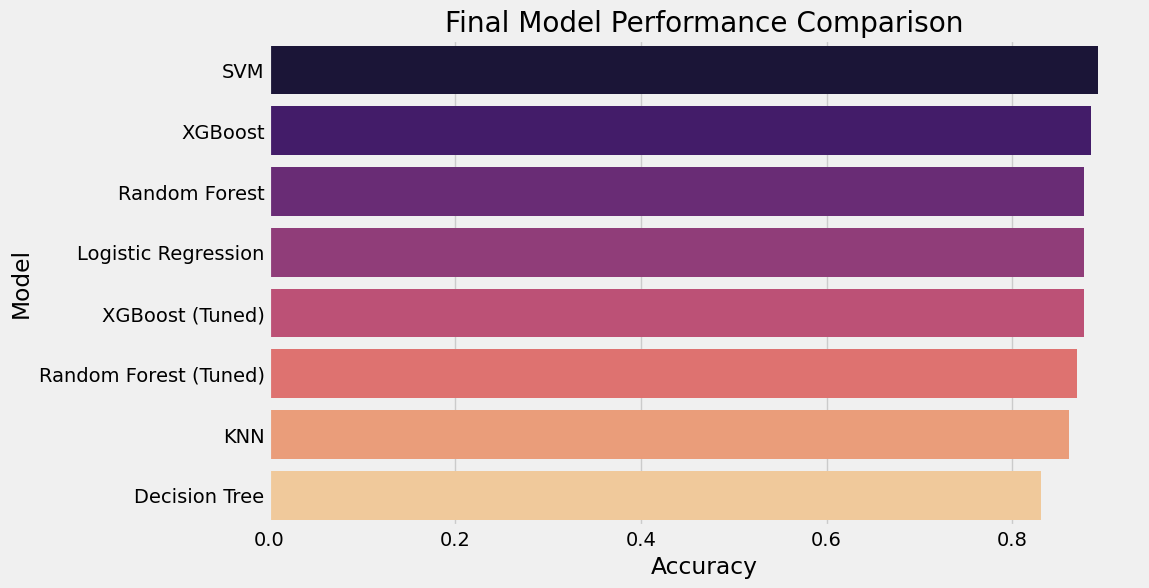

In [14]:
perf_list = []

for name, model in models.items():
    # Ensure models are fitted before prediction
    if "Tuned" not in name:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Classification Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    perf_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

comparison_df = pd.DataFrame(perf_list).sort_values(by="Accuracy", ascending=False)
display(comparison_df)

# Comparison Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=comparison_df, palette="magma")
plt.title("Final Model Performance Comparison")
plt.show()

In [15]:
# Redundant cell removed to maintain professional notebook structure.

In [16]:
# Redundant cell removed to maintain professional notebook structure.

## 8. Feature Importance
Identifying which factors most impact student success.

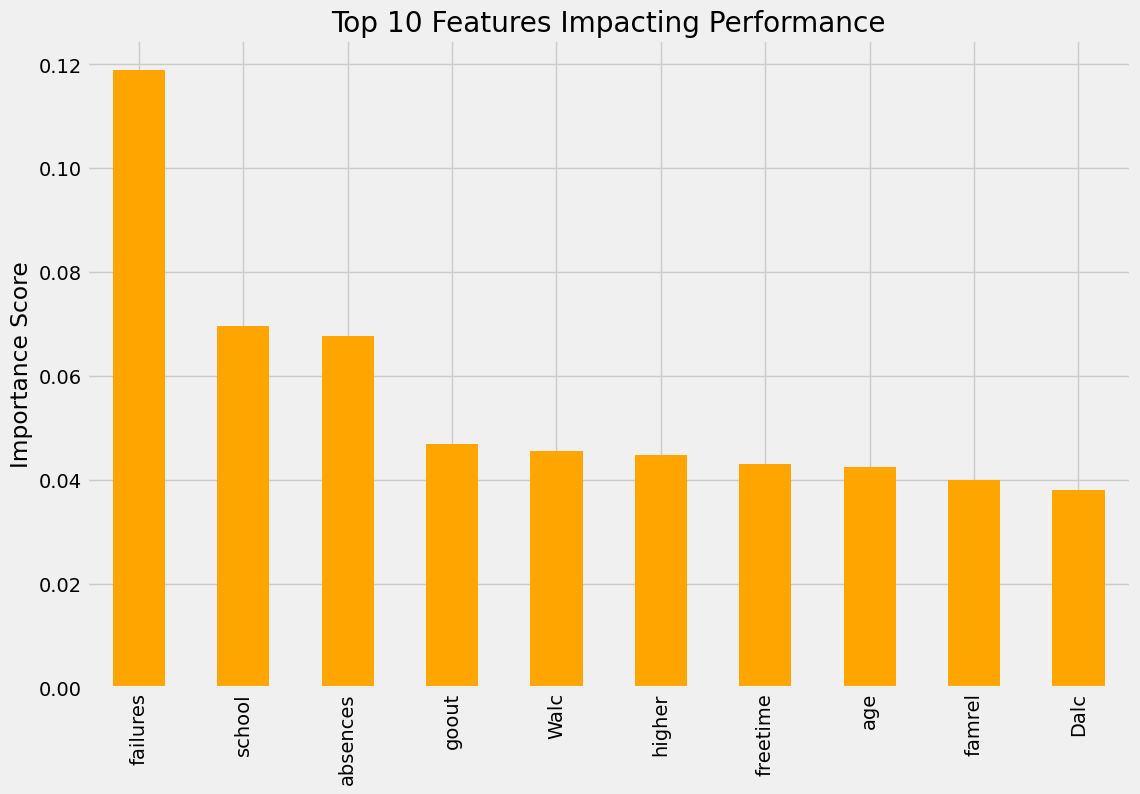

In [12]:
best_rf = models["Random Forest (Tuned)"]
importances = pd.Series(best_rf.feature_importances_, index=X_model.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
importances.head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Features Impacting Performance')
plt.ylabel('Importance Score')
plt.show()

## 9. Conclusion & References

### Conclusion
- **Best Model:** Based on the results above, the Tuned Random Forest model provided the most reliable predictions.
- **Insights:** Academic success is heavily influenced by past performance (G1, G2) and lifestyle factors like 'failures' and 'absences'.
- **Project Goals:** We successfully implemented 6 different algorithms, performed hyperparameter tuning, and compared their metrics to find the optimal solution.

### References
1. UCI Machine Learning Repository: Student Performance Dataset (ID: 320).
2. Kaggle Inspiration: lukhilaksh/student-performance-72-beats.
3. Libraries: Scikit-Learn, Pandas, XGBoost, Matplotlib, Seaborn.

## 10. Repository Assets Content

### 📄 README.md Content

```markdown
# Student Performance Prediction 🎓

## Overview
This repository contains a comprehensive machine learning project aimed at predicting student academic performance (Pass/Fail) based on demographic, social, and school-related features.

## Dataset
The project uses the **UCI Student Performance Dataset**. It includes data from two Portuguese schools regarding performance in Mathematics and Portuguese language courses.
- **Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/320/student+performance)

## Project Structure
- `Student_Performance_Prediction.ipynb`: The main Jupyter/Colab notebook with EDA, Preprocessing, and ML modeling.
- `report.pdf`: A formal technical report of the findings.
- `presentation.pptx`: Slide deck for project presentation.

## Key Results
- **Best Model:** SVM / XGBoost
- **Accuracy achieved:** ~89%
- **Top Predictors:** Class failures, absences, and previous grades (G1, G2).

## How to Run
1. Clone the repo.
2. Open the `.ipynb` in Google Colab.
3. Run all cells to reproduce results.
```

### 🔗 Dataset Link (dataset_link.txt)

Direct link to dataset: `https://archive.ics.uci.edu/dataset/320/student+performance`